In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Clean white theme apply karne ke liye
plt.style.use('seaborn-v0_8-whitegrid')

# Consistent colors select karo (Retained = Blue, Churned = Orange/Red)
colors = {0: '#1f77b4', 1: '#ff7f0e'}

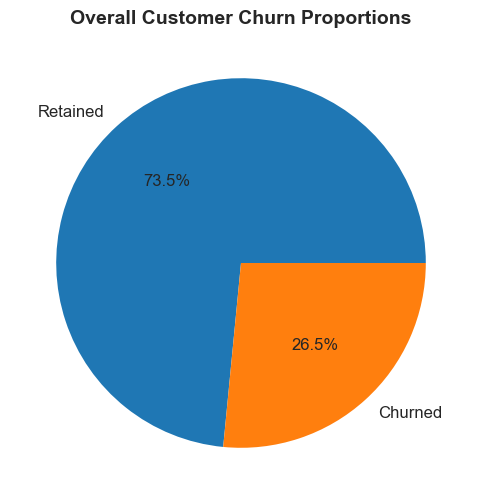

In [9]:
plt.figure(figsize=(6, 6))
df = pd.read_csv('C:/Users/rishabh chaturvedi/Downloads/churn_cleaned_for_analyst.csv')
df['churn_value'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#1f77b4', '#ff7f0e'], labels=['Retained', 'Churned'], fontsize=12)
plt.title('Overall Customer Churn Proportions', fontsize=14, fontweight='bold')
plt.ylabel('') # Takki default label hat jaye

# Save the chart
plt.savefig('charts/churned_vs_retained.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
print(df.columns)

Index(['customerid', 'city', 'zip_code', 'latitude', 'longitude', 'gender',
       'senior_citizen', 'partner', 'dependents', 'tenure_months',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn_value',
       'churn_score', 'cltv', 'churn_reason', 'monthly_charges_outlier_flag',
       'total_charges_outlier_flag', 'tenure_months_outlier_flag',
       'churn_score_outlier_flag', 'cltv_outlier_flag', 'revenue_per_month',
       'total_to_monthly_charge_ratio', 'tenure_group',
       'is_long_term_customer', 'churn_risk_band', 'num_services_subscribed',
       'contract_numeric', 'is_digital_payment'],
      dtype='object')


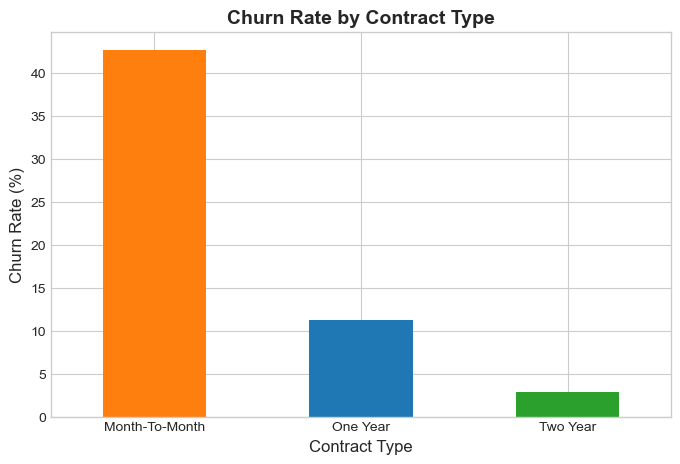

In [12]:
plt.figure(figsize=(8, 5))
contract_churn = df.groupby('contract')['churn_value'].mean() * 100
contract_churn.plot(kind='bar', color=['#ff7f0e', '#1f77b4', '#2ca02c'])
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=0)
plt.savefig('charts/churn_by_contract_type.png', dpi=150, bbox_inches='tight')
plt.show()

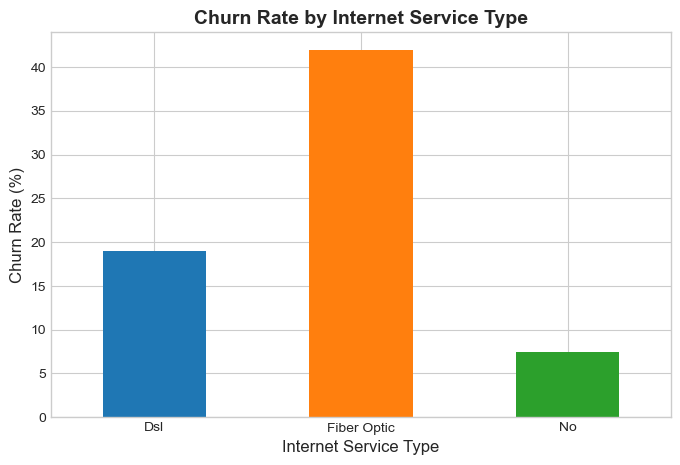

In [15]:
plt.figure(figsize=(8, 5))
internet_churn = df.groupby('internet_service')['churn_value'].mean() * 100
internet_churn.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Churn Rate by Internet Service Type', fontsize=14, fontweight='bold')
plt.xlabel('Internet Service Type', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=0)
plt.savefig('charts/churn_by_internet_service.png', dpi=150, bbox_inches='tight')
plt.show()

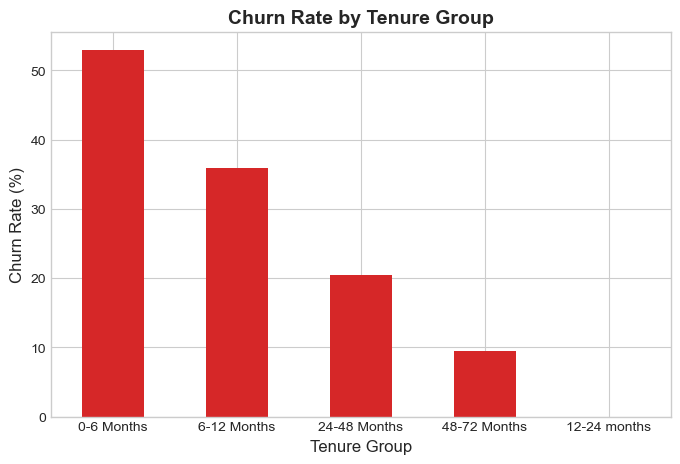

In [18]:
plt.figure(figsize=(8, 5))
tenure_churn = df.groupby('tenure_group')['churn_value'].mean() * 100
# Sahi order me lagane ke liye (agar automatic order galat ho)
order = ['0-6 Months', '6-12 Months', '24-48 Months', '48-72 Months','12-24 months']
tenure_churn = tenure_churn.reindex(order, fill_value=0)

tenure_churn.plot(kind='bar', color='#d62728')
plt.title('Churn Rate by Tenure Group', fontsize=14, fontweight='bold')
plt.xlabel('Tenure Group', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=0)
plt.savefig('charts/churn_by_tenure_group.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
print(df['tenure_group'].unique())

['0-6 Months' '6-12 Months' '24-48 Months' '48-72 Months' '12-24 Months']


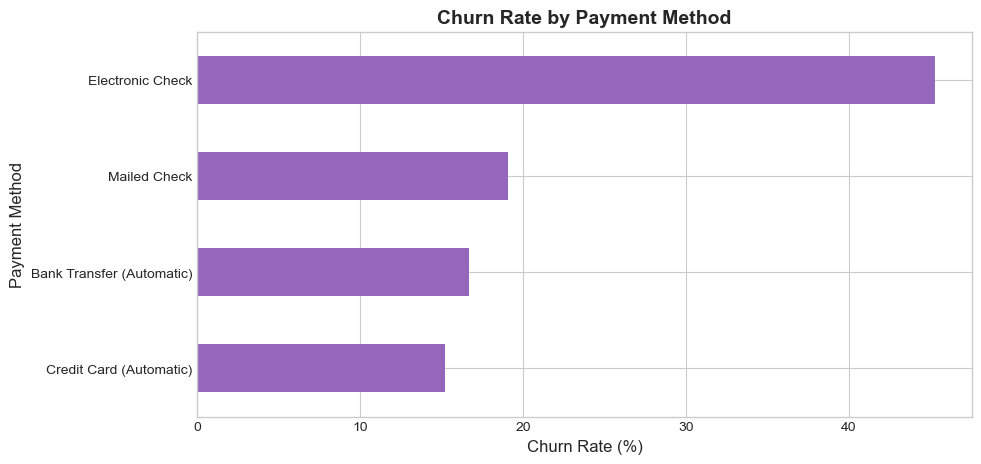

In [21]:
plt.figure(figsize=(10, 5))
payment_churn = df.groupby('payment_method',)['churn_value'].mean() * 100
payment_churn.sort_values().plot(kind='barh', color='#9467bd')
plt.title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Churn Rate (%)', fontsize=12)
plt.ylabel('Payment Method', fontsize=12)
plt.savefig('charts/churn_by_payment_method.png', dpi=150, bbox_inches='tight')
plt.show()

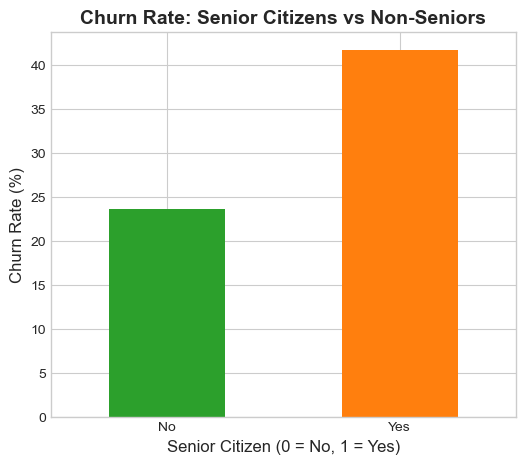

In [22]:
plt.figure(figsize=(6, 5))
senior_churn = df.groupby('senior_citizen')['churn_value'].mean() * 100
senior_churn.plot(kind='bar', color=['#2ca02c', '#ff7f0e'])
plt.title('Churn Rate: Senior Citizens vs Non-Seniors', fontsize=14, fontweight='bold')
plt.xlabel('Senior Citizen (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=0)
plt.savefig('charts/churn_by_senior_citizen.png', dpi=150, bbox_inches='tight')
plt.show()

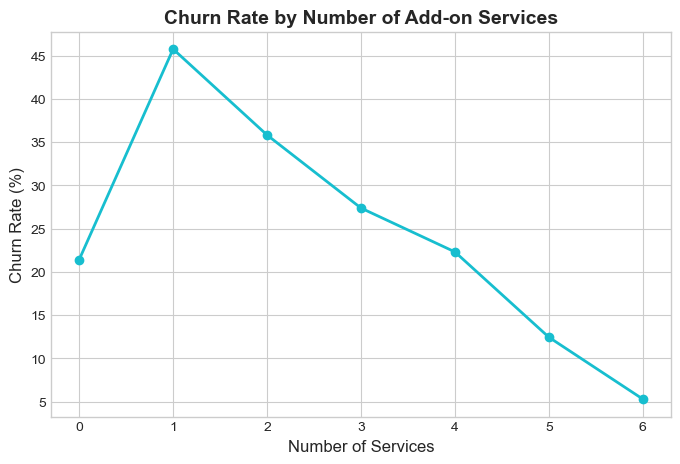

In [23]:
plt.figure(figsize=(8, 5))
services_churn = df.groupby('num_services_subscribed')['churn_value'].mean() * 100
plt.plot(services_churn.index, services_churn.values, marker='o', linewidth=2, color='#17becf')
plt.title('Churn Rate by Number of Add-on Services', fontsize=14, fontweight='bold')
plt.xlabel('Number of Services', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.savefig('charts/churn_by_num_services.png', dpi=150, bbox_inches='tight')
plt.show()

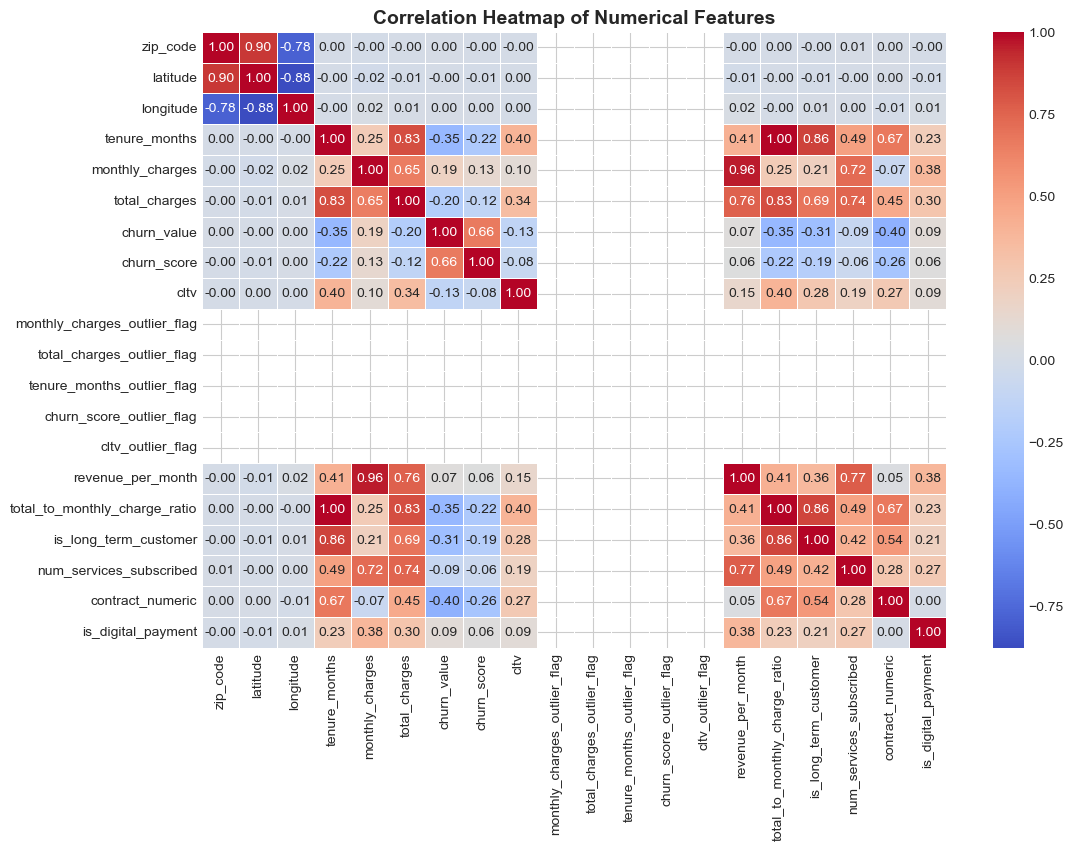

In [24]:
plt.figure(figsize=(12, 8))
# Sirf numerical columns select karo
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, annot_kws={"size": 10})
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.savefig('charts/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

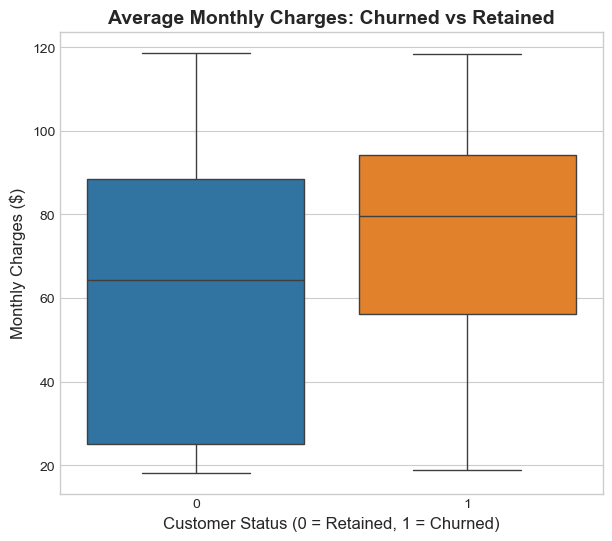

In [31]:
plt.figure(figsize=(7, 6))
sns.boxplot(x='churn_value', y='monthly_charges',hue='churn_value',legend=False, data=df, palette=['#1f77b4', '#ff7f0e'])
plt.title('Average Monthly Charges: Churned vs Retained', fontsize=14, fontweight='bold')
plt.xlabel('Customer Status (0 = Retained, 1 = Churned)', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)
plt.savefig('charts/avg_monthly_charge_churned_vs_retained.png', dpi=150, bbox_inches='tight')
plt.show()

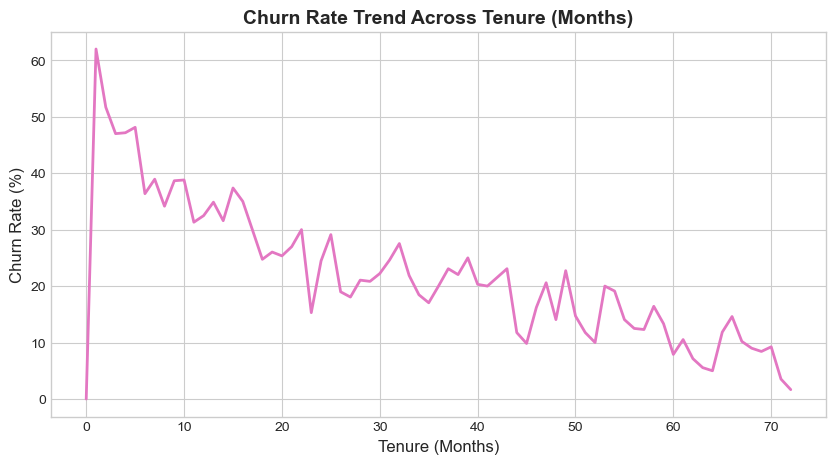

In [32]:
plt.figure(figsize=(10, 5))
tenure_raw_churn = df.groupby('tenure_months')['churn_value'].mean() * 100
plt.plot(tenure_raw_churn.index, tenure_raw_churn.values, color='#e377c2', linewidth=2)
plt.title('Churn Rate Trend Across Tenure (Months)', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.savefig('charts/tenure_vs_churn_rate.png', dpi=150, bbox_inches='tight')
plt.show()

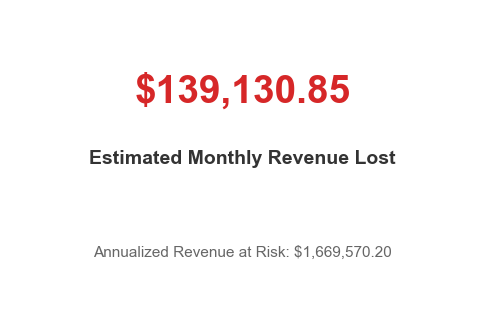

In [39]:
# Math calculation
churned_df = df[df['churn_value'] == 1]
num_churned = len(churned_df)
avg_charge_churned = churned_df['monthly_charges'].mean()
monthly_loss = num_churned * avg_charge_churned
annual_loss = monthly_loss * 12

# Visual plot banana ek blank card ke roop me
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis('off') # Borders hatane ke liye

# Text blocks add karo card par
ax.text(0.5, 0.7, f"${monthly_loss:,.2f}", fontsize=28, fontweight='bold', color='#d62728', ha='center')
ax.text(0.5, 0.5, "Estimated Monthly Revenue Lost", fontsize=14, fontweight='bold', color='#333333', ha='center')
ax.text(0.5, 0.2, f"Annualized Revenue at Risk: ${annual_loss:,.2f}", fontsize=11, color='#666666', ha='center')
plt.savefig('charts/revenue_lost_estimate.png', dpi=150, bbox_inches='tight')
plt.show()